In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
df_train = pd.read_csv('/content/trainset.csv')
df_test = pd.read_csv('/content/testset.csv')

train_prices = df_train['Close'].values.reshape(-1, 1)
test_prices = df_test['Close'].values.reshape(-1, 1)

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)


In [ ]:
def create_sequences(data, seq_length):
    x = []
    y = []

    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(x), np.array(y)


seq_length = 60

x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)

In [ ]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [ ]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RNNModel().to(device)

print("Using device:", device)


Using device: cpu


In [ ]:
import torch
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 64)
        out, _ = self.rnn(x, h0)
        out = out[:, -1, :]
        return self.fc(out)

model = RNNModel()

print("Model input_size:", model.rnn.input_size)

Model input_size: 1


In [ ]:
!pip install torchinfo



In [ ]:
from torchinfo import summary

In [ ]:
!pip install torchinfo


In [ ]:
from torchinfo import summary

In [ ]:
from torchsummary import summary

model = RNNModel(input_size=10, hidden_size=32, num_layers=2, output_size=1)

summary(model, input_size=(5, 10))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
               RNN-1  [[-1, 5, 32], [-1, 2, 32]]               0
            Linear-2                    [-1, 1]              33
Total params: 33
Trainable params: 33
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.00
Estimated Total Size (MB): 0.08
----------------------------------------------------------------


In [ ]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
print("Input tensor shape:", x_train_tensor.shape)
print("Model expects input_size:", model.rnn.input_size)

Input tensor shape: torch.Size([1199, 60, 1])
Model expects input_size: 10


In [ ]:
num_epochs = 30
train_losses = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for inputs, targets in train_loader:

        inputs = inputs.to(device)           # shape: (batch, 60, 1)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)              # forward pass

        loss = criterion(outputs, targets)   # MSE loss

        loss.backward()                      # backprop

        optimizer.step()                     # update weights

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss:.6f}")

Epoch [1/30], Training Loss: 0.351029
Epoch [2/30], Training Loss: 0.350167
Epoch [3/30], Training Loss: 0.351556
Epoch [4/30], Training Loss: 0.351119
Epoch [5/30], Training Loss: 0.350510
Epoch [6/30], Training Loss: 0.351673
Epoch [7/30], Training Loss: 0.349528
Epoch [8/30], Training Loss: 0.349182
Epoch [9/30], Training Loss: 0.352312
Epoch [10/30], Training Loss: 0.350914
Epoch [11/30], Training Loss: 0.350648
Epoch [12/30], Training Loss: 0.349791
Epoch [13/30], Training Loss: 0.350146
Epoch [14/30], Training Loss: 0.350182
Epoch [15/30], Training Loss: 0.351014
Epoch [16/30], Training Loss: 0.349736
Epoch [17/30], Training Loss: 0.350634
Epoch [18/30], Training Loss: 0.349935
Epoch [19/30], Training Loss: 0.351378
Epoch [20/30], Training Loss: 0.350770
Epoch [21/30], Training Loss: 0.350353
Epoch [22/30], Training Loss: 0.351000
Epoch [23/30], Training Loss: 0.350820
Epoch [24/30], Training Loss: 0.350699
Epoch [25/30], Training Loss: 0.349780
Epoch [26/30], Training Loss: 0.35

Name: Mithun Kumar G 
Register Number: 212224230160


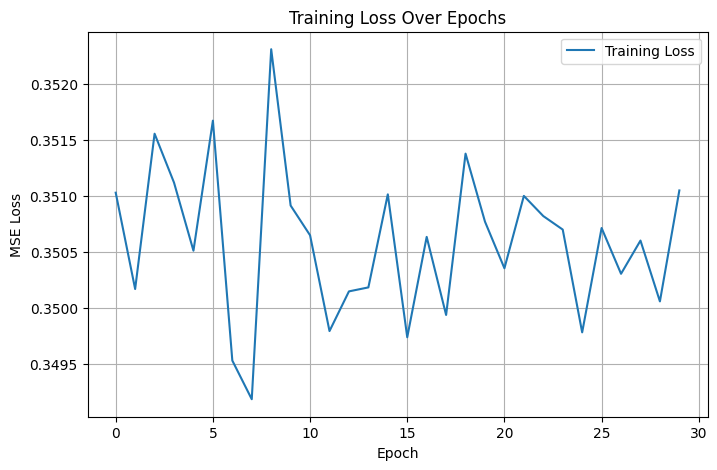

In [ ]:
print('Name: Mithun Kumar G ')
print('Register Number: 212224230160')

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid()
plt.show()

In [ ]:
model.eval()

with torch.no_grad():

    predicted = model(x_test_tensor.to(device))
    predicted = predicted.cpu().numpy()

    actual = y_test_tensor.cpu().numpy()


In [ ]:
model.eval()

with torch.no_grad():
    predicted = model(x_test_tensor.to(device)).cpu().numpy()
    actual = y_test_tensor.cpu().numpy()

predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(actual)

Name: Mithun Kumar G 
Register Number:212224230160


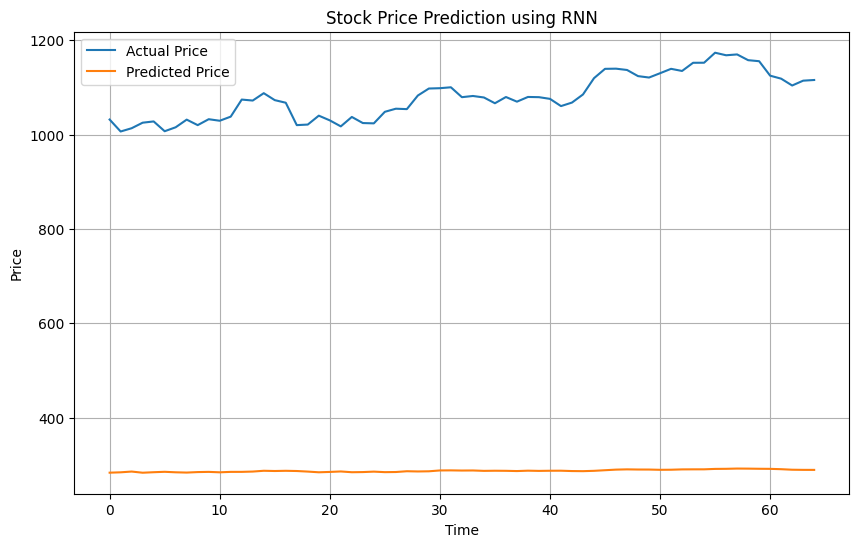

In [ ]:
print('Name: Mithun Kumar G ')
print('Register Number:212224230160')

plt.figure(figsize=(10,6))

plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction using RNN')

plt.legend()
plt.grid()

plt.show()


In [ ]:
print(f"Last Predicted Price: {predicted_prices[-1][0]:.2f}")
print(f"Last Actual Price:    {actual_prices[-1][0]:.2f}")

Last Predicted Price: 289.18
Last Actual Price:    1115.65
